In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [2]:
df = pd.read_csv("../dataset/cleaned_data.csv")

df.head()

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.70,4.0,324.0,4.0,bank transfer,2.0,2024-06-14,1.0
1,TC-000692,59.389947,Female,3.446551,Month-to-month,98.48,251.15,DSL,No,9.46,1.0,306.8,4.0,Electronic check,5.0,2024-06-23,1.0
2,TC-000066,62.343600,Male,1.386582,Two year,94.35,120.78,Fiber optic,Yes,9.56,4.0,349.5,4.0,Bank transfer,0.0,2024-06-21,0.0
3,TC-003427,45.788533,Female,67.609659,Month-to-month,85.87,5834.73,Fiber optic,Yes,3.15,1.0,258.2,4.7,Credit card,4.0,2024-06-21,1.0
4,TC-004821,39.625418,Female,27.319623,One year,62.14,1626.23,DSL,Yes,28.80,0.0,335.8,4.0,Credit card,2.0,2024-06-19,0.0


In [3]:
# df["charge_per_month"] = (
#     df["total_charges"] /
#     (df["tenure_months"] + 1)
# )

# df["support_ticket_rate"] = (
#     df["num_support_tickets"] /
#     (df["tenure_months"] + 1)
# )


df["charge_per_month"] = np.where(
    df["tenure_months"] > 0,
    df["total_charges"] / df["tenure_months"],
    df["monthly_charges"]
)

df["support_ticket_rate"] = np.where(
    df["tenure_months"] > 0,
    df["num_support_tickets"] / df["tenure_months"],
    df["num_support_tickets"]
)

In [4]:
X = df.drop(
    columns=[
        "customer_id",
        "churned",
        "last_interaction_date"
    ]
)

y = df["churned"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

numeric_features = X_train.select_dtypes(
    exclude="object"
).columns.tolist()

print(categorical_features)

print(numeric_features)

['gender', 'contract_type', 'internet_service', 'phone_service', 'payment_method']
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes', 'satisfaction_score', 'num_additional_services', 'charge_per_month', 'support_ticket_rate']


In [7]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

### Logistic Regression Pipeline

In [9]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

In [10]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','gender','tenure_months',...,'num_additional_services', 'charge_per_month','support_ticket_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [11]:
logistic_pred = logistic_pipeline.predict(X_test)

logistic_prob = logistic_pipeline.predict_proba(X_test)[:,1]

### Random Forest Pipeline

In [12]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_estimators=200
            )
        )
    ]
)

In [13]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','gender','tenure_months',...,'num_additional_services', 'charge_per_month','support_ticket_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [14]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

## Evaluation Function

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions
        ),
        "Recall": recall_score(
            y_true,
            predictions
        ),
        "F1 Score": f1_score(
            y_true,
            predictions
        ),
        "ROC AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

In [16]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

results = pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.662,0.555556,0.369863,0.444079,0.690899
1,Random Forest,0.652,0.534694,0.358904,0.429508,0.679819


##### Metric Selection

For customer churn prediction, **Recall** is the most important metric.

A false negative means a customer who is actually at risk of churn is predicted as safe, resulting in a missed retention opportunity and potential revenue loss.

While Precision is also important to avoid unnecessary retention efforts, businesses typically prefer contacting a few extra customers rather than missing customers who are likely to leave.

Accuracy can be misleading when class imbalance exists, as a model may achieve high accuracy simply by predicting the majority class.

In [17]:
y_train.value_counts()

churned
0.0    2542
1.0    1458
Name: count, dtype: int64

In [18]:
y_train.value_counts(normalize=True)

churned
0.0    0.6355
1.0    0.3645
Name: proportion, dtype: float64

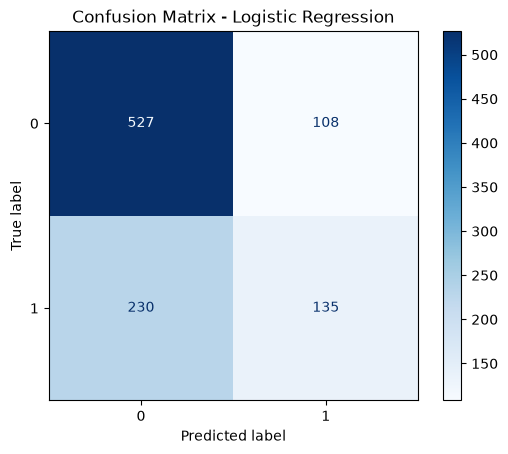

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, logistic_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        logistic_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.70      0.83      0.76       635
         1.0       0.56      0.37      0.44       365

    accuracy                           0.66      1000
   macro avg       0.63      0.60      0.60      1000
weighted avg       0.64      0.66      0.64      1000



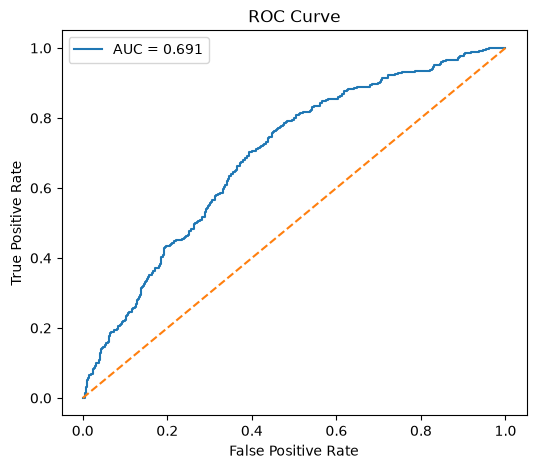

In [21]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    logistic_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, logistic_prob):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

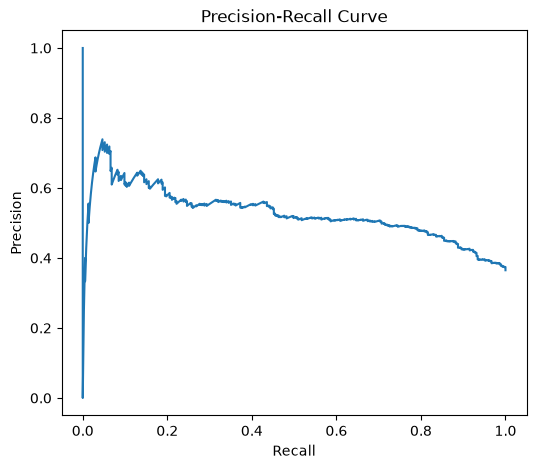

In [22]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    logistic_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [23]:
feature_names = (
    logistic_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_pipeline.named_steps["model"]
    .coef_[0]
)

importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Importance": np.abs(coefficients)
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance.head(20)

,Feature,Coefficient,Importance
15,cat__contract_type_Month-to-month,0.765320,0.765320
17,cat__contract_type_Two year,-0.565873,0.565873
16,cat__contract_type_One year,-0.518168,0.518168
11,cat__gender_Female,-0.320880,0.320880
27,cat__payment_method_CC,-0.256332,0.256332
25,cat__payment_method_BT,0.206785,0.206785
3,num__total_charges,-0.200300,0.200300
24,cat__phone_service_Yes,-0.184414,0.184414
21,cat__internet_service_dsl,-0.172969,0.172969
13,cat__gender_Male,-0.153687,0.153687


In [24]:
import joblib

joblib.dump(
    logistic_pipeline,
    "../saved_models/churn_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [25]:
y_train.value_counts(normalize=True)

churned
0.0    0.6355
1.0    0.3645
Name: proportion, dtype: float64

### The dataset shows a moderate class distribution (63.5% retained vs. 36.5% churned). Since the imbalance is not severe, no class rebalancing techniques were applied. Baseline Logistic Regression produced the best overall performance among the evaluated models.

In [26]:
import shap

X_test_processed = logistic_pipeline.named_steps[
    "preprocessor"
].transform(X_test)

model = logistic_pipeline.named_steps["model"]

In [27]:
feature_names = (
    logistic_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [28]:
explainer = shap.LinearExplainer(
    model,
    X_test_processed
)

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


In [29]:
shap_values = explainer(X_test_processed)

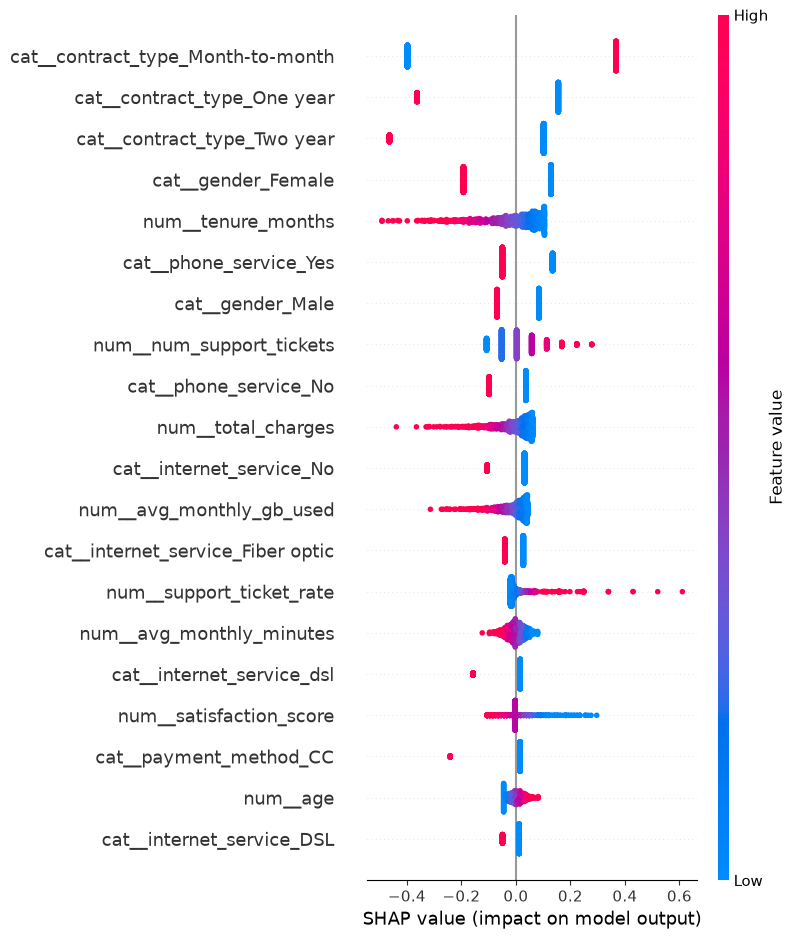

In [30]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [31]:
joblib.dump(
    logistic_pipeline,
    "../saved_models/churn_model.pkl"
)

['../saved_models/churn_model.pkl']

In [32]:
joblib.dump(
    feature_names,
    "../saved_models/feature_names.pkl"
)

['../saved_models/feature_names.pkl']